# Infer KVAE 2D

In [1]:
import torch

from kvae_2d.model import KVAE2D
from kvae_2d.utils import ImageDataset, show_image, compute_psnr_range

In [2]:
device = "cuda:0"
dtype = torch.bfloat16

In [12]:
model = KVAE2D.from_pretrained("kandinskylab/KVAE-2D-1.0")
model = model.to(dtype).to(device).eval()

In [30]:
dataset = ImageDataset("./assets/images/")
len(dataset)

4

In [31]:
sample = dataset[1].unsqueeze(0).to(dtype).to(device)
with torch.no_grad():
    output = model(sample)
print("PSNR: ", compute_psnr_range(sample, output['x_hat']))

PSNR:  tensor(39.0063, device='cuda:0')


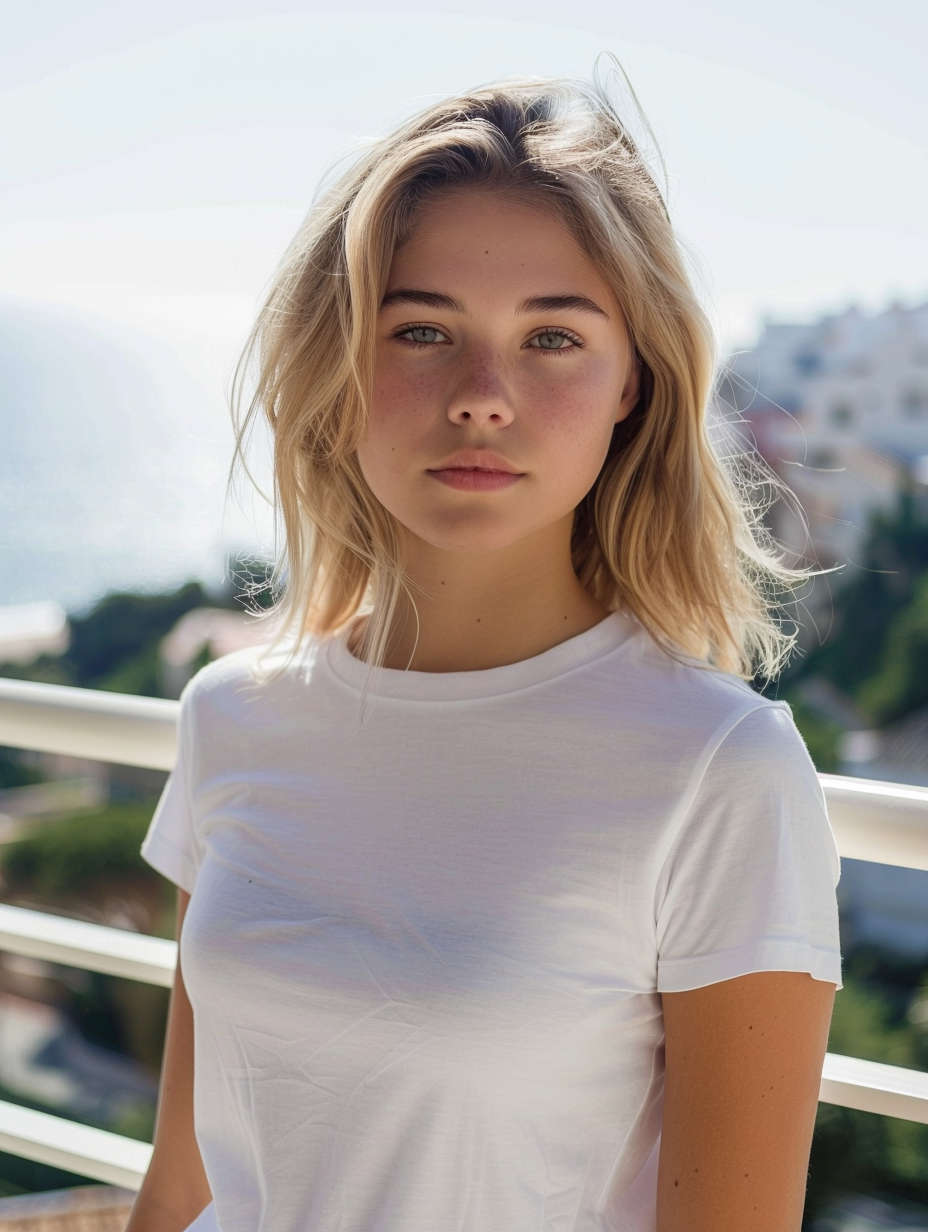

In [32]:
show_image(output['x_hat'])